In [1]:
# ============================================================
# 📦 Cell 1: 패키지 임포트
# ============================================================

import os
import json
import time
import re
import requests
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from PIL import Image
from io import BytesIO
from tqdm import tqdm
from pathlib import Path

print("✅ 패키지 임포트 완료")

✅ 패키지 임포트 완료


In [2]:
# ============================================================
# 🏗️ Cell 2: 디렉토리 생성
# ============================================================

PROJECT_ROOT = Path(".")  # 프로젝트 루트 = 현재 디렉토리
DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = DATA_DIR / "player_images"
EMBEDDINGS_DIR = DATA_DIR / "embeddings"
META_DIR = DATA_DIR / "metadata"

for d in [IMAGES_DIR, EMBEDDINGS_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"✅ 프로젝트 디렉토리 생성 완료: {PROJECT_ROOT.resolve()}")
print(f"   📁 이미지:     {IMAGES_DIR}")
print(f"   📁 임베딩:     {EMBEDDINGS_DIR}")
print(f"   📁 메타데이터: {META_DIR}")

✅ 프로젝트 디렉토리 생성 완료: /Users/young/Desktop/Naco/Projects/kbo-lookalike
   📁 이미지:     data/player_images
   📁 임베딩:     data/embeddings
   📁 메타데이터: data/metadata


In [3]:
# ============================================================
# 🔍 Cell 3: KBO 상수 & 수집 함수 정의
#
# 페이징 구조 확인 완료:
#   ucPager$btnNo1, btnNo2, ... btnNo5 → 페이지 번호
#   ucPager$btnFirst / btnLast → 처음/마지막
#   __EVENTTARGET에 위 컨트롤 ID를 넣으면 PostBack 동작
#   __EVENTARGUMENT는 빈 문자열
# ============================================================

KBO_TEAMS = {
    "HH": "한화 이글스",
    "OB": "두산 베어스",
    "HT": "KIA 타이거즈",
    "SS": "삼성 라이온즈",
    "LG": "LG 트윈스",
    "SK": "SSG 랜더스",
    "KT": "KT 위즈",
    "NC": "NC 다이노스",
    "LT": "롯데 자이언츠",
    "WO": "키움 히어로즈",
}

BASE_URL = "https://www.koreabaseball.com"
SEARCH_URL = f"{BASE_URL}/Player/Search.aspx"
IMAGE_CDN = "https://6ptotvmi5753.edge.naverncp.com/KBO_IMAGE/person/middle"

PAGER_PREFIX = "ctl00$ctl00$ctl00$cphContents$cphContents$cphContents$ucPager$"
TEAM_FIELD = "ctl00$ctl00$ctl00$cphContents$cphContents$cphContents$ddlTeam"
POS_FIELD = "ctl00$ctl00$ctl00$cphContents$cphContents$cphContents$ddlPosition"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/131.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "ko-KR,ko;q=0.9,en-US;q=0.8,en;q=0.7",
    "Referer": SEARCH_URL,
}


def extract_asp_fields(soup):
    """ASP.NET hidden 필드 추출"""
    fields = {}
    for name in ["__VIEWSTATE", "__EVENTVALIDATION", "__VIEWSTATEGENERATOR"]:
        tag = soup.find("input", {"name": name})
        fields[name] = tag["value"] if tag else ""
    return fields


def parse_players_from_soup(soup, team_code):
    """HTML에서 선수 정보 파싱"""
    players = []
    links = soup.find_all("a", href=re.compile(r"playerId=\d+"))

    for link in links:
        href = link.get("href", "")
        m = re.search(r"playerId=(\d+)", href)
        if not m:
            continue

        name = link.get_text(strip=True)
        if not name or len(name) < 2:
            continue

        position = "투수" if "Pitcher" in href else "타자"

        players.append({
            "player_id": m.group(1),
            "name": name,
            "team_code": team_code,
            "team_name": KBO_TEAMS.get(team_code, team_code),
            "position": position,
            "detail_url": (BASE_URL + href) if href.startswith("/") else href,
        })

    return players


def get_pager_info(soup):
    """
    현재 페이지의 페이저 상태를 파악합니다.
    Returns: (현재 페이지 번호, 사용 가능한 btnNo 목록, btnLast 존재 여부)
    """
    paging_div = soup.find("div", class_="paging")
    if not paging_div:
        return 1, [], False

    # 현재 페이지 = <strong> 또는 <span class="on"> 등 활성 표시
    current_page = 1
    strong = paging_div.find("strong")
    if strong and strong.get_text(strip=True).isdigit():
        current_page = int(strong.get_text(strip=True))

    # 클릭 가능한 페이지 번호들
    available_btns = []
    btn_links = paging_div.find_all("a", href=re.compile(r"ucPager\$btnNo\d+"))
    for link in btn_links:
        text = link.get_text(strip=True)
        if text.isdigit():
            available_btns.append(int(text))

    # btnLast(마지막 페이지) 존재 여부 = 더 많은 페이지가 있다는 뜻
    has_last = bool(paging_div.find("a", href=re.compile(r"ucPager\$btnLast")))
    # btnNext(다음 그룹) 존재 여부
    has_next = bool(paging_div.find("a", href=re.compile(r"ucPager\$btnNext")))

    return current_page, available_btns, has_last or has_next


def do_postback(session, asp_fields, event_target, team_code):
    """ASP.NET PostBack 요청을 수행합니다."""
    form_data = {
        **asp_fields,
        "__EVENTTARGET": event_target,
        "__EVENTARGUMENT": "",
        TEAM_FIELD: team_code,
        POS_FIELD: "",
    }
    resp = session.post(SEARCH_URL, data=form_data)
    resp.raise_for_status()
    return BeautifulSoup(resp.text, "html.parser")


def fetch_all_players_for_team(session, team_code, asp_fields):
    """
    팀의 전체 선수를 수집합니다.
    ucPager$btnNo1~5 → 다음 그룹(btnNext) → 반복
    """
    all_players = []
    visited_pages = set()

    # Step 1: 팀 필터 선택 (첫 페이지 로드)
    soup = do_postback(session, asp_fields, TEAM_FIELD, team_code)
    asp_fields = extract_asp_fields(soup)

    page_players = parse_players_from_soup(soup, team_code)
    all_players.extend(page_players)
    visited_pages.add(1)

    time.sleep(0.5)

    # Step 2: 페이지 순회
    max_iterations = 20  # 안전장치 (20 × 20명 = 400명 한도)
    iterations = 0

    while iterations < max_iterations:
        iterations += 1
        current, available_btns, has_more = get_pager_info(soup)

        # 아직 방문하지 않은 페이지 번호 찾기
        unvisited = [b for b in available_btns if b not in visited_pages]

        if unvisited:
            # 다음 미방문 페이지로 이동
            next_page = min(unvisited)
            btn_name = f"{PAGER_PREFIX}btnNo{((next_page - 1) % 5) + 1}"

            soup = do_postback(session, asp_fields, btn_name, team_code)
            asp_fields = extract_asp_fields(soup)

            page_players = parse_players_from_soup(soup, team_code)
            if not page_players:
                break

            all_players.extend(page_players)
            visited_pages.add(next_page)
            time.sleep(0.5)

        elif has_more:
            # 현재 그룹(1-5) 다 봤고, 다음 그룹이 있으면 btnNext 클릭
            # btnNext가 없으면 btnLast 시도 후 역추적
            paging_div = soup.find("div", class_="paging")
            next_link = paging_div.find("a", href=re.compile(r"ucPager\$btnNext"))
            if next_link:
                soup = do_postback(session, asp_fields, f"{PAGER_PREFIX}btnNext", team_code)
            else:
                # btnNext 없으면 마지막 그룹이므로 남은 번호만 처리
                break

            asp_fields = extract_asp_fields(soup)
            # 새 그룹의 첫 페이지는 자동 로드됨
            page_players = parse_players_from_soup(soup, team_code)
            if not page_players:
                break

            # 새 그룹의 현재 페이지 번호 파악
            new_current, new_btns, _ = get_pager_info(soup)
            all_players.extend(page_players)
            visited_pages.add(new_current)
            time.sleep(0.5)

        else:
            # 더 이상 페이지 없음
            break

    # 중복 제거 (같은 선수가 여러 페이지에 나올 수 있음)
    seen = set()
    unique = []
    for p in all_players:
        if p["player_id"] not in seen:
            seen.add(p["player_id"])
            unique.append(p)

    return unique, asp_fields


print("✅ 수집 함수 정의 완료 (v3 — ucPager 지원)")
print(f"   대상: {len(KBO_TEAMS)}개 구단")
print(f"   페이저: ucPager$btnNo1~5 + btnNext + btnLast")

✅ 수집 함수 정의 완료 (v3 — ucPager 지원)
   대상: 10개 구단
   페이저: ucPager$btnNo1~5 + btnNext + btnLast


In [4]:
# ============================================================
# 🏃 Cell 4: 전체 팀 선수 목록 수집
#
# 각 팀별로 ucPager를 순회하여 전체 선수를 수집합니다.
# 한화 기준 5페이지 → 약 80~100명 예상
# 10개 팀 합계 → 총 500~700명 예상
#
# ⏱️ 예상: 5~10분
# ============================================================

print("🔄 KBO 선수 목록 수집 시작 (v3 페이징)...\n")

# 세션 초기화
session = requests.Session()
session.headers.update(HEADERS)
resp = session.get(SEARCH_URL)
soup = BeautifulSoup(resp.text, "html.parser")
asp_fields = extract_asp_fields(soup)

all_players = []

for team_code, team_name in tqdm(KBO_TEAMS.items(), desc="팀별 수집"):
    try:
        players, asp_fields = fetch_all_players_for_team(
            session, team_code, asp_fields
        )
        all_players.extend(players)
        print(f"  ✅ {team_name} ({team_code}): {len(players)}명")
    except Exception as e:
        print(f"  ❌ {team_name} ({team_code}): {e}")
        import traceback
        traceback.print_exc()

    time.sleep(2)

# 전체 중복 제거
seen = set()
unique = []
for p in all_players:
    if p["player_id"] not in seen:
        seen.add(p["player_id"])
        unique.append(p)
all_players = unique

# 저장
df_players = pd.DataFrame(all_players)
csv_path = META_DIR / "kbo_players.csv"
df_players.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"\n📊 총 수집된 선수: {len(all_players)}명")
print(f"💾 CSV 저장: {csv_path}")

if len(df_players) > 0:
    print(f"\n📋 팀별 선수 수:")
    for team, count in df_players.groupby("team_name").size().sort_values(ascending=False).items():
        print(f"   {team}: {count}명")

df_players.head(10)

🔄 KBO 선수 목록 수집 시작 (v3 페이징)...



팀별 수집:   0%|          | 0/10 [00:00<?, ?it/s]

  ✅ 한화 이글스 (HH): 89명


팀별 수집:  10%|█         | 1/10 [00:05<00:47,  5.25s/it]

  ✅ 두산 베어스 (OB): 86명


...

팀별 수집:  90%|█████████ | 9/10 [00:48<00:05,  5.56s/it]

  ✅ 키움 히어로즈 (WO): 91명


팀별 수집: 100%|██████████| 10/10 [00:53<00:00,  5.35s/it]


📊 총 수집된 선수: 945명
💾 CSV 저장: data/metadata/kbo_players.csv

📋 팀별 선수 수:
   롯데 자이언츠: 105명
   NC 다이노스: 100명
   KIA 타이거즈: 99명
   삼성 라이온즈: 96명
   SSG 랜더스: 95명
   LG 트윈스: 94명
   키움 히어로즈: 91명
   KT 위즈: 90명
   한화 이글스: 89명
   두산 베어스: 86명


,player_id,name,team_code,team_name,position,detail_url
0,56769,강건우,HH,한화 이글스,투수,https://www.koreabaseball.com/Record/Player/Pi...
1,68050,강백호,HH,한화 이글스,타자,https://www.koreabaseball.com/Record/Player/Hi...
2,50705,강재민,HH,한화 이글스,투수,https://www.koreabaseball.com/Record/Player/Pi...
3,52769,권광민,HH,한화 이글스,타자,https://www.koreabaseball.com/Record/Player/Hi...
4,55764,권민규,HH,한화 이글스,투수,https://www.koreabaseball.com/Record/Player/Pi...
5,56794,권현규,HH,한화 이글스,타자,https://www.koreabaseball.com/Record/Player/Hi...
6,69702,김건,HH,한화 이글스,타자,https://www.koreabaseball.com/Futures/Player/H...
7,52703,김겸재,HH,한화 이글스,투수,https://www.koreabaseball.com/Futures/Player/P...
8,53701,김관우,HH,한화 이글스,투수,https://www.koreabaseball.com/Futures/Player/P...
9,54705,김도빈,HH,한화 이글스,투수,https://www.koreabaseball.com/Record/Player/Pi...


In [5]:
# ============================================================
# 📸 Cell 5-HQ: 고화질 선수 프로필 이미지 다운로드
#
# 1차: 다음 스포츠 CDN (1050x1350, 고화질)
#   URL: https://t1.daumcdn.net/sports/player/300/1/{playerId}.jpg
# 2차: KBO CDN 폴백 (100x130, 저해상도)
#   URL: {IMAGE_CDN}/{year}/{playerId}.jpg
#
# KBO playerId == 다음 playerId 동일 확인됨
# 저장 경로: data/player_images_high/
#
# ⏱️ 예상: 10~20분 (0.5초 간격)
# ============================================================

DAUM_CDN = "https://t1.daumcdn.net/sports/player/300/1"
CURRENT_YEAR = "2025"
FALLBACK_YEARS = ["2024", "2023", "2022"]

IMAGES_HQ_DIR = DATA_DIR / "player_images_high"
IMAGES_HQ_DIR.mkdir(parents=True, exist_ok=True)


def download_player_image_hq(player_id, save_dir):
    """고화질 선수 프로필 이미지 다운로드. 다음 → KBO 순차 시도."""
    save_path = save_dir / f"{player_id}.jpg"

    # 이미 다운로드 완료된 경우 스킵
    if save_path.exists() and save_path.stat().st_size > 1000:
        return save_path, "skipped", None

    # 1차: 다음 스포츠 CDN
    daum_url = f"{DAUM_CDN}/{player_id}.jpg"
    try:
        resp = requests.get(daum_url, headers=HEADERS, timeout=10)
        if resp.status_code == 200 and len(resp.content) > 5000:
            img = Image.open(BytesIO(resp.content))
            if img.size[0] >= 200 and img.size[1] >= 200:
                if img.mode != "RGB":
                    img = img.convert("RGB")
                img.save(save_path, "JPEG", quality=95)
                return save_path, "daum", img.size
    except Exception:
        pass

    # 2차: KBO CDN 폴백 (연도 순차)
    for year in [CURRENT_YEAR] + FALLBACK_YEARS:
        url = f"{IMAGE_CDN}/{year}/{player_id}.jpg"
        try:
            resp = requests.get(url, headers=HEADERS, timeout=10)
            if resp.status_code == 200 and len(resp.content) > 1000:
                img = Image.open(BytesIO(resp.content))
                if img.size[0] > 50 and img.size[1] > 50:
                    if img.mode != "RGB":
                        img = img.convert("RGB")
                    img.save(save_path, "JPEG", quality=95)
                    return save_path, f"kbo_fallback ({year})", img.size
        except Exception:
            continue

    return None, "not_found", None


# === 실행 ===
print("🔄 고화질 선수 프로필 이미지 다운로드 시작...\n")

stats = {"daum": 0, "kbo_fallback": 0, "skipped": 0, "not_found": 0}
sizes = []
total = len(df_players)

for i, (_, row) in enumerate(df_players.iterrows(), 1):
    name = row.get("name", row["player_id"])
    pid = row["player_id"]
    _, status, size = download_player_image_hq(pid, IMAGES_HQ_DIR)

    icon = ""
    if status == "daum":
        stats["daum"] += 1
        icon = "🌟"
        if size:
            sizes.append(size)
        time.sleep(0.5)
    elif "kbo_fallback" in status:
        stats["kbo_fallback"] += 1
        icon = "📉"
        if size:
            sizes.append(size)
        time.sleep(0.5)
    elif status == "skipped":
        stats["skipped"] += 1
        icon = "⏭️"
    else:
        stats["not_found"] += 1
        icon = "❌"

    # 실시간 진행 로그
    d, k, s, n = stats["daum"], stats["kbo_fallback"], stats["skipped"], stats["not_found"]
    print(
        f"\r[{i:>4}/{total}] {icon} {name:<10s} ({pid}) | "
        f"🌟{d} 📉{k} ⏭️{s} ❌{n}",
        end="", flush=True
    )

print()  # 마지막 줄바꿈

print(f"\n📊 다운로드 결과:")
print(f"   🌟 다음 고화질:  {stats['daum']}명")
print(f"   📉 KBO 폴백:    {stats['kbo_fallback']}명")
print(f"   ⏭️ 이미 존재:    {stats['skipped']}명")
print(f"   ❌ 이미지 없음:  {stats['not_found']}명")

if sizes:
    avg_w = sum(s[0] for s in sizes) / len(sizes)
    avg_h = sum(s[1] for s in sizes) / len(sizes)
    print(f"\n📐 새로 받은 이미지 평균 해상도: {avg_w:.0f}x{avg_h:.0f}")

# 유효한 이미지가 있는 선수만 필터
valid_ids = {
    f.stem for f in IMAGES_HQ_DIR.glob("*.jpg")
    if f.stat().st_size > 1000
}
df_with_images = df_players[df_players["player_id"].isin(valid_ids)].copy()
print(f"\n✅ 유효한 이미지 보유 선수: {len(df_with_images)}명")

🔄 고화질 선수 프로필 이미지 다운로드 시작...

[ 945/945] 📉 한민우        (53096) | 🌟760 📉3 ⏭️0 ❌182

📊 다운로드 결과:
   🌟 다음 고화질:  760명
   📉 KBO 폴백:    3명
   ⏭️ 이미 존재:    0명
   ❌ 이미지 없음:  182명

📐 새로 받은 이미지 평균 해상도: 2332x2767

✅ 유효한 이미지 보유 선수: 763명


Matplotlib is building the font cache; this may take a moment.
/var/folders/nj/9nc70myx31134b08twnnw67r0000gn/T/ipykernel_8059/2132229690.py:34: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/young/Desktop/Naco/Projects/kbo-lookalike/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


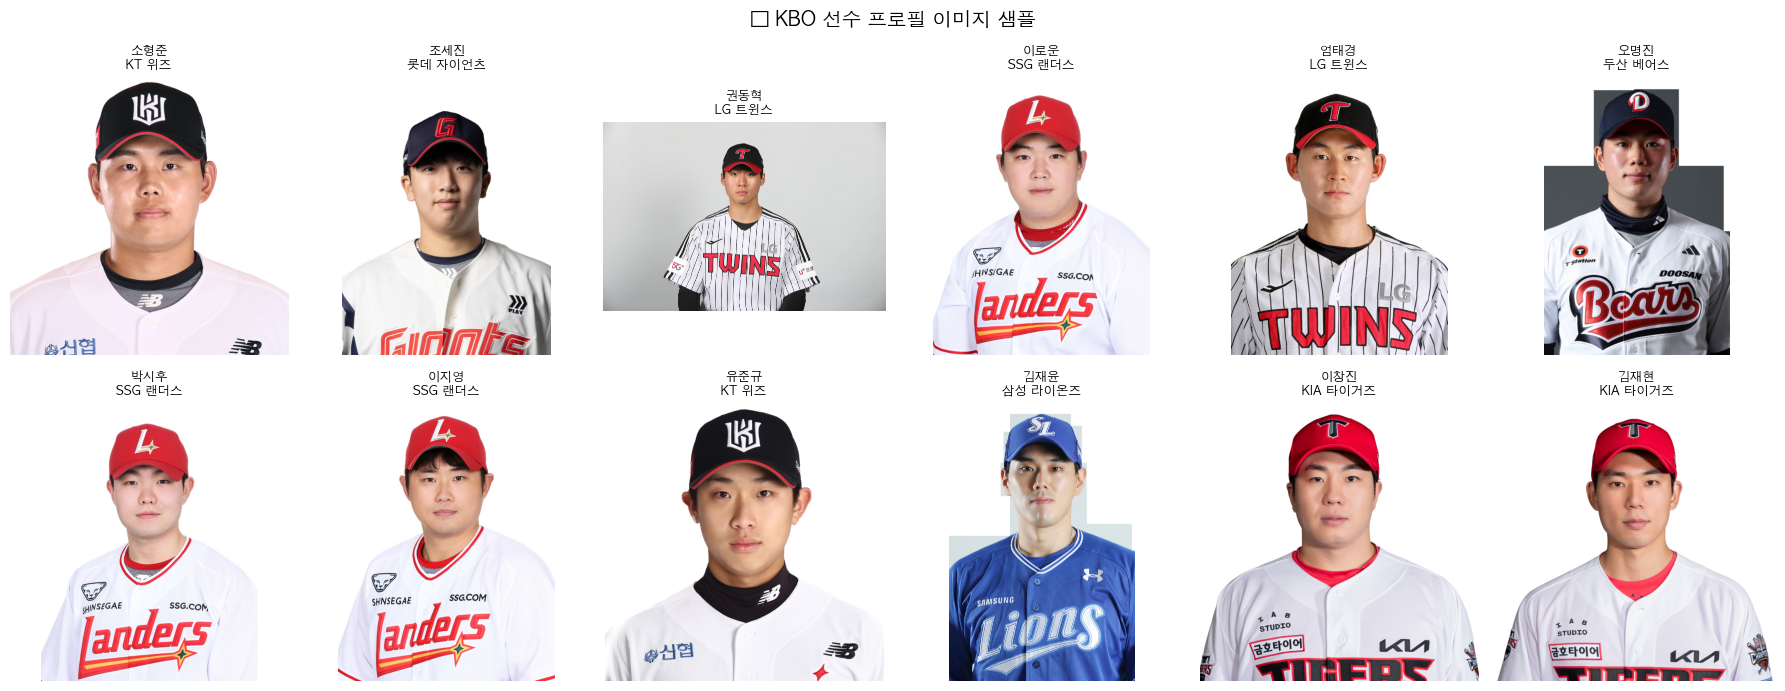

In [6]:
# ============================================================
# 👁️ Cell 6: 다운로드 이미지 샘플 미리보기
# ============================================================

import matplotlib.pyplot as plt
import random

# 한글 폰트 설정 (macOS)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

n_samples = min(12, len(df_with_images))
samples = df_with_images.sample(n_samples).to_dict("records")

cols = min(6, n_samples)
rows = (n_samples + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3.5 * rows))
if rows == 1 and cols == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, player in enumerate(samples):
    img_path = IMAGES_HQ_DIR / f"{player['player_id']}.jpg"  # HQ 디렉토리로 변경
    if img_path.exists():
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{player['name']}\n{player['team_name']}", fontsize=9)
    axes[i].axis("off")

for i in range(len(samples), len(axes)):
    axes[i].axis("off")

plt.suptitle("📸 KBO 선수 프로필 이미지 샘플", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 🧠 Cell 7: InsightFace 모델 로드
#
# buffalo_sc = InsightFace 경량 모델 패키지:
#   - SCRFD → 얼굴 검출 (bbox + 5-point 랜드마크)
#   - MobileFaceNet (ArcFace) → 512-D 얼굴 임베딩
#
# ⭐ 이 모델의 ONNX 버전을 나중에 브라우저에서도 동일하게 사용합니다!
# 즉, 여기서 추출한 임베딩과 브라우저에서 추출한 임베딩이
# 동일한 벡터 공간에 있어야 유사도 비교가 의미 있습니다.
#
# ⏱️ 첫 실행 시 모델 다운로드 ~2분
# ============================================================

from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name="buffalo_sc",
    root=str(PROJECT_ROOT / "models"),
    providers=["CPUExecutionProvider"],
)
app.prepare(ctx_id=0, det_size=(640, 640))

print("✅ InsightFace 모델 로드 완료")
print("   📦 패키지: buffalo_sc")
print("   🔍 Detection: SCRFD")
print("   🧬 Recognition: MobileFaceNet (ArcFace, 512-D)")

download_path: models/models/buffalo_sc


100%|██████████| 14619/14619 [00:01<00:00, 10603.42KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models/models/buffalo_sc/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
✅ InsightFace 모델 로드 완료
   📦 패키지: buffalo_sc
   🔍 Detection: SCRFD
   🧬 Recognition: MobileFaceNet (ArcFace, 512-D)


In [8]:
# ============================================================
# 🔢 Cell 8: 전체 선수 임베딩 추출
#
# 각 선수 이미지에서:
#   1. SCRFD → 얼굴 검출 + 5-point 랜드마크
#   2. 랜드마크 기반 어파인 변환 → 112×112 정렬된 얼굴
#   3. MobileFaceNet (ArcFace) → 512-D 임베딩
#   4. L2 정규화 (코사인 유사도 = 내적이 되도록)
#
# ⏱️ 예상: 3~10분 (CPU 기준)
# ============================================================

import cv2


def extract_embedding(face_app, image_path):
    """이미지 → 512-D 정규화된 얼굴 임베딩"""
    img = cv2.imread(str(image_path))
    if img is None:
        return None, "이미지 로드 실패"

    faces = face_app.get(img)

    if len(faces) == 0:
        return None, "얼굴 미검출"

    face = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))

    emb = face.embedding
    emb = emb / np.linalg.norm(emb)
    return emb, "success"


# === 실행 ===
print("🔄 선수 임베딩 추출 시작...\n")

embeddings_dict = {}
stats = {"success": 0, "no_face": 0, "error": 0}

for _, player in tqdm(df_with_images.iterrows(), total=len(df_with_images), desc="임베딩 추출"):
    pid = player["player_id"]
    img_path = IMAGES_HQ_DIR / f"{pid}.jpg"  # 고화질 이미지 디렉토리

    try:
        emb, status = extract_embedding(app, img_path)
        if emb is not None:
            embeddings_dict[pid] = emb.tolist()
            stats["success"] += 1
        else:
            stats["no_face"] += 1
            print(f"  ⚠️ {player['name']} ({pid}): {status}")
    except Exception as e:
        stats["error"] += 1
        print(f"  ❌ {player['name']} ({pid}): {e}")

print(f"\n📊 임베딩 추출 결과:")
print(f"   ✅ 성공:       {stats['success']}명")
print(f"   ⚠️ 얼굴 미검출: {stats['no_face']}명")
print(f"   ❌ 에러:       {stats['error']}명")

🔄 선수 임베딩 추출 시작...



임베딩 추출:   0%|          | 0/763 [00:00<?, ?it/s]/Users/young/Desktop/Naco/Projects/kbo-lookalike/.venv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
임베딩 추출: 100%|██████████| 763/763 [00:27<00:00, 27.67it/s]


📊 임베딩 추출 결과:
   ✅ 성공:       763명
   ⚠️ 얼굴 미검출: 0명
   ❌ 에러:       0명


In [9]:
# ============================================================
# 💾 Cell 9: 서비스용 JSON 저장
#
# 브라우저에서 사용할 2개 파일 생성:
#   1. player_embeddings.json — 유사도 계산용 벡터
#   2. player_metadata.json  — UI 표시용 선수 정보
#
# 이 파일들이 나중에 CDN에 올라갑니다.
# ============================================================

# === 1. 임베딩 JSON ===
embeddings_output = {
    "version": "1.0",
    "model": "buffalo_sc (MobileFaceNet / ArcFace)",
    "dimension": 512,
    "count": len(embeddings_dict),
    "players": embeddings_dict,
}

emb_path = EMBEDDINGS_DIR / "player_embeddings.json"
with open(emb_path, "w") as f:
    json.dump(embeddings_output, f)

emb_mb = emb_path.stat().st_size / (1024 * 1024)
print(f"💾 임베딩 저장: {emb_path}")
print(f"   선수 수: {len(embeddings_dict)}명")
print(f"   파일 크기: {emb_mb:.2f} MB  (gzip 시 ~{emb_mb * 0.35:.2f} MB)")


# === 2. 메타데이터 JSON ===
valid_pids = set(embeddings_dict.keys())
metadata_list = []

for _, p in df_with_images.iterrows():
    pid = p["player_id"]
    if pid in valid_pids:
        metadata_list.append({
            "id": pid,
            "name": p["name"],
            "team": p["team_name"],
            "teamCode": p["team_code"],
            "position": p["position"],
            "imageUrl": f"/images/players/{pid}.jpg",
        })

meta_output = {
    "version": "1.0",
    "count": len(metadata_list),
    "players": metadata_list,
}

meta_path = META_DIR / "player_metadata.json"
with open(meta_path, "w") as f:
    json.dump(meta_output, f, ensure_ascii=False, indent=2)

print(f"\n💾 메타데이터 저장: {meta_path}")
print(f"   선수 수: {len(metadata_list)}명")

💾 임베딩 저장: data/embeddings/player_embeddings.json
   선수 수: 763명
   파일 크기: 8.20 MB  (gzip 시 ~2.87 MB)

💾 메타데이터 저장: data/metadata/player_metadata.json
   선수 수: 763명


In [10]:
# ============================================================
# 🧪 Cell 10: 닮은꼴 테스트 — 임베딩 품질 검증
#
# 특정 선수 기준 → 가장 유사한 Top-5 선수를 찾습니다.
# 이 과정이 나중에 브라우저에서 유저 얼굴로 동일하게 수행됩니다!
#
# ⭐ 여기 결과가 "그럴듯"하면 파인튜닝 없이 서비스 가능!
# ============================================================

import random


def cosine_similarity(a, b):
    """이미 L2 정규화된 벡터이므로 내적 = 코사인 유사도"""
    return float(np.dot(a, b))


def find_top_similar(target_id, embeddings, metadata, top_n=5):
    """target_id 선수와 가장 유사한 Top-N 선수 반환"""
    if target_id not in embeddings:
        return []

    target = np.array(embeddings[target_id])
    sims = []

    for pid, emb in embeddings.items():
        if pid == target_id:
            continue
        sims.append((pid, cosine_similarity(target, np.array(emb))))

    sims.sort(key=lambda x: x[1], reverse=True)

    meta_map = {p["id"]: p for p in metadata}
    return [
        {**meta_map[pid], "similarity": round(sim, 4)}
        for pid, sim in sims[:top_n]
        if pid in meta_map
    ]


# === 랜덤 선수 3명으로 테스트 ===
meta_map = {p["id"]: p for p in metadata_list}
test_ids = random.sample(list(embeddings_dict.keys()), min(3, len(embeddings_dict)))

for pid in test_ids:
    info = meta_map.get(pid, {})
    print(f"\n🎯 기준: {info.get('name', pid)} ({info.get('team', '?')})")
    print("-" * 50)

    results = find_top_similar(pid, embeddings_dict, metadata_list, top_n=5)
    for rank, r in enumerate(results, 1):
        pct = r["similarity"] * 100
        print(f"  {rank}위: {r['name']} ({r['team']}) — 유사도 {pct:.1f}%")


🎯 기준: 김준원 (NC 다이노스)
--------------------------------------------------
  1위: 오정환 (KIA 타이거즈) — 유사도 47.4%
  2위: 이준혁 (NC 다이노스) — 유사도 44.3%
  3위: 조수행 (두산 베어스) — 유사도 43.2%
  4위: 홍성호 (두산 베어스) — 유사도 42.9%
  5위: 장규빈 (두산 베어스) — 유사도 42.2%

🎯 기준: 이지강 (LG 트윈스)
--------------------------------------------------
  1위: 박진 (롯데 자이언츠) — 유사도 49.9%
  2위: 김대현 (LG 트윈스) — 유사도 48.1%
  3위: 김건 (한화 이글스) — 유사도 44.9%
  4위: 이재익 (삼성 라이온즈) — 유사도 44.0%
  5위: 김태경 (NC 다이노스) — 유사도 43.6%

🎯 기준: 오정환 (KIA 타이거즈)
--------------------------------------------------
  1위: 최준호 (두산 베어스) — 유사도 52.7%
  2위: 우정안 (LG 트윈스) — 유사도 51.5%
  3위: 신명승 (KIA 타이거즈) — 유사도 50.6%
  4위: 정해영 (KIA 타이거즈) — 유사도 49.9%
  5위: 김지윤 (두산 베어스) — 유사도 49.3%


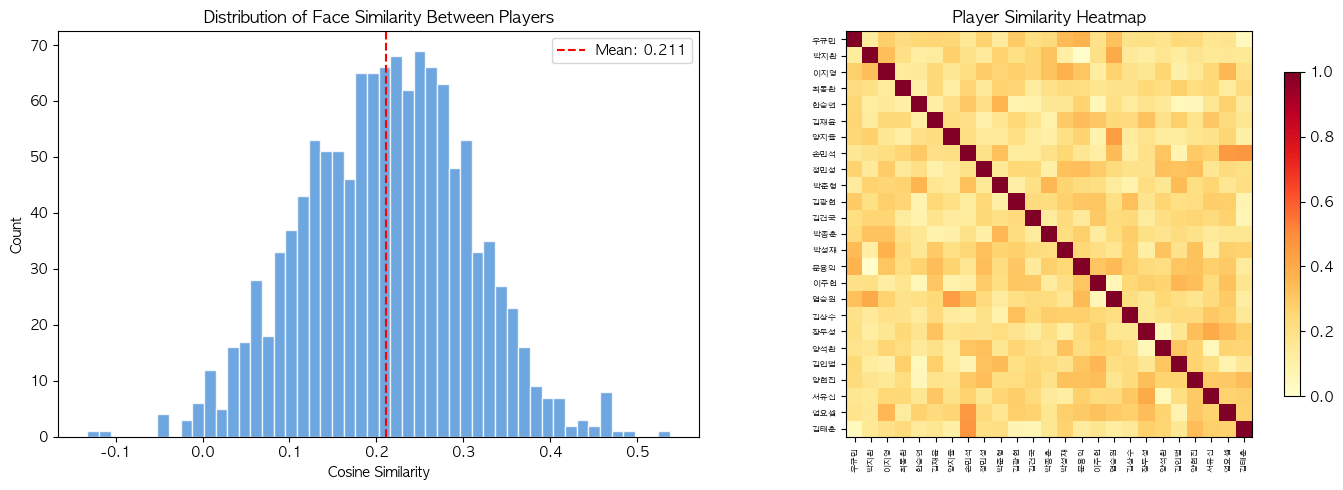


📈 유사도 통계:
   평균:   0.2110
   표준편차: 0.0954
   최소:   -0.1323
   최대:   0.5373
   중앙값: 0.2143


In [11]:
# ============================================================
# 📊 Cell 11: 유사도 분포 시각화
#
# 전체 선수 간 유사도 분포를 확인합니다.
# - 평균이 0.2~0.4 부근이면 정상 (다양한 얼굴을 잘 구분)
# - 평균이 0.6 이상이면 모델이 구분을 잘 못하는 것
# ============================================================

import matplotlib.pyplot as plt

# 50명 샘플링 → 유사도 매트릭스
sample_ids = random.sample(list(embeddings_dict.keys()), min(50, len(embeddings_dict)))
sample_embs = np.array([embeddings_dict[pid] for pid in sample_ids])

# 정규화된 벡터 내적 = 코사인 유사도 매트릭스
sim_matrix = sample_embs @ sample_embs.T

# 대각선(자기자신=1.0) 제외, 상삼각만
mask = np.triu(np.ones_like(sim_matrix, dtype=bool), k=1)
all_sims = sim_matrix[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 히스토그램
axes[0].hist(all_sims, bins=50, color="#4A90D9", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Face Similarity Between Players")
axes[0].axvline(np.mean(all_sims), color="red", linestyle="--",
                label=f"Mean: {np.mean(all_sims):.3f}")
axes[0].legend()

# (우) 히트맵 (25명)
n = min(25, len(sample_ids))
small = sim_matrix[:n, :n]
names = [meta_map.get(pid, {}).get("name", pid)[:4] for pid in sample_ids[:n]]

im = axes[1].imshow(small, cmap="YlOrRd", vmin=0, vmax=1)
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
axes[1].set_xticklabels(names, rotation=90, fontsize=6)
axes[1].set_yticklabels(names, fontsize=6)
axes[1].set_title("Player Similarity Heatmap")
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print(f"\n📈 유사도 통계:")
print(f"   평균:   {np.mean(all_sims):.4f}")
print(f"   표준편차: {np.std(all_sims):.4f}")
print(f"   최소:   {np.min(all_sims):.4f}")
print(f"   최대:   {np.max(all_sims):.4f}")
print(f"   중앙값: {np.median(all_sims):.4f}")

In [12]:
# ============================================================
# 🌐 Cell 12: 브라우저용 ONNX 모델 내보내기
# ============================================================

import shutil
import subprocess

export_dir = PROJECT_ROOT / "browser_models"
export_dir.mkdir(exist_ok=True)

# InsightFace 모델 파일 위치 탐색
search_paths = [
    PROJECT_ROOT / "models" / "models" / "buffalo_sc",
    Path.home() / ".insightface" / "models" / "buffalo_sc",
]

found = []
for sp in search_paths:
    if sp.exists():
        found.extend(sp.glob("*.onnx"))

if found:
    print("📦 발견된 ONNX 모델:")
    for f in found:
        mb = f.stat().st_size / (1024 * 1024)
        print(f"   {f.name}: {mb:.2f} MB")
        shutil.copy2(f, export_dir / f.name)

    print(f"\n✅ 브라우저용 모델 복사 완료: {export_dir}")
    print("   이 .onnx 파일들을 웹 서버에 올려서")
    print("   ONNX Runtime Web으로 로드하면 됩니다.")
else:
    print("⚠️ ONNX 파일을 자동으로 찾지 못했습니다.")
    print("   아래에서 탐색 중...\n")
    result = subprocess.run(
        ["find", str(Path.home()), "-name", "*.onnx", "-path", "*buffalo*"],
        capture_output=True, text=True, timeout=30
    )
    if result.stdout.strip():
        print(result.stdout.strip())
    else:
        print("   찾을 수 없습니다. InsightFace 모델이 다운로드되었는지 확인하세요.")

📦 발견된 ONNX 모델:
   det_500m.onnx: 2.41 MB
   w600k_mbf.onnx: 12.99 MB

✅ 브라우저용 모델 복사 완료: browser_models
   이 .onnx 파일들을 웹 서버에 올려서
   ONNX Runtime Web으로 로드하면 됩니다.


In [13]:
# ============================================================
# ✅ Cell 13: 최종 요약 & 다음 단계
# ============================================================

print("=" * 60)
print("🎉 KBO 선수 데이터 수집 파이프라인 완료!")
print("=" * 60)

files = {
    "선수 메타데이터 CSV":   META_DIR / "kbo_players.csv",
    "선수 메타데이터 JSON":  META_DIR / "player_metadata.json",
    "선수 임베딩 JSON":     EMBEDDINGS_DIR / "player_embeddings.json",
    "선수 이미지 폴더":     IMAGES_HQ_DIR,              # 고화질 디렉토리로 변경
    "브라우저용 ONNX 모델":  PROJECT_ROOT / "browser_models",
}

print(f"\n📂 프로젝트 경로: {PROJECT_ROOT.resolve()}\n")  # Google Drive → 로컬 절대경로

for desc, path in files.items():
    if path.exists():
        if path.is_dir():
            cnt = len(list(path.glob("*")))
            print(f"  ✅ {desc}: {cnt}개 파일")
        else:
            kb = path.stat().st_size / 1024
            if kb > 1024:
                print(f"  ✅ {desc}: {kb/1024:.1f} MB")
            else:
                print(f"  ✅ {desc}: {kb:.0f} KB")
    else:
        print(f"  ❌ {desc}: 없음")

# 이하 print문 동일

🎉 KBO 선수 데이터 수집 파이프라인 완료!

📂 프로젝트 경로: /Users/young/Desktop/Naco/Projects/kbo-lookalike

  ✅ 선수 메타데이터 CSV: 115 KB
  ✅ 선수 메타데이터 JSON: 143 KB
  ✅ 선수 임베딩 JSON: 8.2 MB
  ✅ 선수 이미지 폴더: 763개 파일
  ✅ 브라우저용 ONNX 모델: 2개 파일
